## HR Analytics Employee Attrition Prediction Project

This notebook aims to predict employee attrition using the IBM HR Attrition dataset. We will perform a comprehensive analysis, including data preprocessing, model selection, hyperparameter tuning, and interpretability, to build a robust and business-relevant attrition prediction model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data=pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
data.shape

(1470, 35)

In [ ]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
data["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


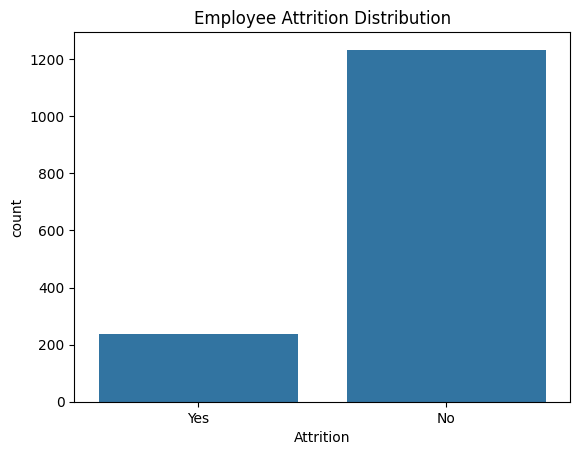

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=data)

plt.title('Employee Attrition Distribution')
plt.show()

In [ ]:
columns_to_drop = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

# Drop columns only if they exist
data = data.drop(columns=[col for col in columns_to_drop if col in data.columns], axis=1)

In [ ]:
data.shape

(1470, 31)

In [ ]:
pd.crosstab(data['OverTime'], data['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


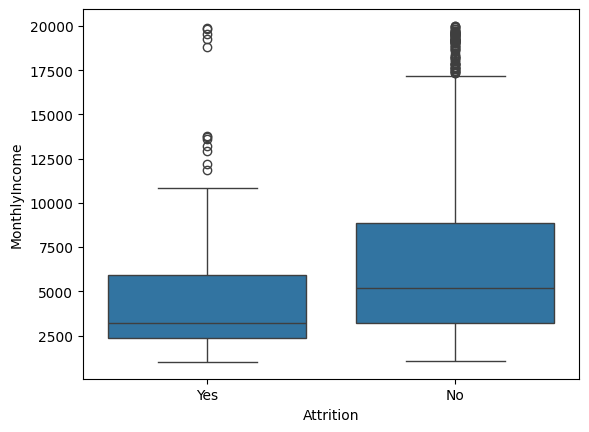

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=data
)

plt.show()

In [ ]:
pd.crosstab(
    data['JobSatisfaction'],
    data['Attrition']
)

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


In [ ]:
pd.crosstab(
    data['WorkLifeBalance'],
    data['Attrition']
)

Attrition,No,Yes
WorkLifeBalance,,
1,55,25
2,286,58
3,766,127
4,126,27


In [ ]:
pd.crosstab(
    data['Department'],
    data['Attrition']
)

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [ ]:
y = data['Attrition']
y

,Attrition
0,Yes
1,No
2,Yes
3,No
4,No
...,...
1465,No
1466,No
1467,No
1468,No


In [ ]:
y = y.map({
    'No':0,
    'Yes':1
})
y

,Attrition
0,1
1,0
2,1
3,0
4,0
...,...
1465,0
1466,0
1467,0
1468,0


### 1. Analysis of Class Imbalance

Employee attrition datasets are typically imbalanced, with far fewer employees leaving ('Yes') than staying ('No'). It's important to understand this imbalance as it can significantly affect model training and evaluation metrics, especially recall for the minority class.

From the previous `data['Attrition'].value_counts()` output, we observed:  
-   **No:** 1233  
-   **Yes:** 237  

This indicates a significant class imbalance, where the 'No' class is much larger than the 'Yes' class. This imbalance needs to be addressed during model training and evaluation to ensure the model can effectively identify employees at risk of attrition.

In [ ]:
print(data['Attrition'].head())

0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: object


In [ ]:
X = data.drop('Attrition', axis=1)
y = data['Attrition'].map({'No':0, 'Yes':1})
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X = pd.get_dummies(X, drop_first=True)
X.shape

(1470, 44)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 2. Feature Scaling

Scaling features is a crucial preprocessing step for many machine learning algorithms, especially those that rely on distance calculations or gradient descent (like Logistic Regression). It helps prevent features with larger numerical ranges from dominating the learning process and can improve model convergence.

We will use `StandardScaler` to transform the features so they have a mean of 0 and a standard deviation of 1.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Re-loading the dataset from the verified path to resolve NameError
data = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Drop non-predictive columns
X = data.drop(['Attrition', 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, errors='ignore')
y = data['Attrition'].map({'No': 0, 'Yes': 1})

# Categorical encoding
X = pd.get_dummies(X, drop_first=True)

# Stratified split to maintain class ratios
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE for imbalance handling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Preprocessing fixed and data re-loaded. X_train_scaled and X_train_smote are now available.")

Preprocessing fixed and data re-loaded. X_train_scaled and X_train_smote are now available.


### 3. Review of Preprocessing Pipeline (after Scaling)

Now that feature scaling has been applied, let's re-evaluate the Logistic Regression models. The `ConvergenceWarning` encountered earlier with Logistic Regression is often resolved by scaling the input features. This step is essential for algorithms sensitive to the scale of the data.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Re-run Logistic Regression with scaled data
model_scaled = LogisticRegression(max_iter=1000, random_state=42)
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)

print("--- Logistic Regression (Scaled Data) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))

--- Logistic Regression (Scaled Data) ---
Accuracy: 0.8605442176870748
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Re-run Balanced Logistic Regression with scaled data
lr_balanced_scaled = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_balanced_scaled.fit(X_train_scaled, y_train)
y_pred_lr_balanced_scaled = lr_balanced_scaled.predict(X_test_scaled)

print("--- Balanced Logistic Regression (Scaled Data) ---")
print(classification_report(y_test, y_pred_lr_balanced_scaled))

--- Balanced Logistic Regression (Scaled Data) ---
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



### 4. Advanced Model Comparison with Imbalance Handling (SMOTE)

To meet HR business requirements, we need to prioritize Recall (identifying as many true leavers as possible). We will now implement:
1. **SMOTE** (Synthetic Minority Over-sampling Technique) to balance the training set.
2. **Random Forest and LightGBM** models.
3. **Model Evaluation Table** comparing Accuracy, Precision, Recall, and F1-Score.

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, accuracy_score
import pandas as pd

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Define models
models = {
    "Random Forest (SMOTE)": RandomForestClassifier(random_state=42),
    "LightGBM (SMOTE)": LGBMClassifier(random_state=42, verbose=-1, importance_type='gain'),
    "Logistic Regression (Balanced Weights)": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
}

results = []

for name, model in models.items():
    if "SMOTE" in name:
        model.fit(X_train_smote, y_train_smote)
    else:
        model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

                                    Model  Accuracy  Precision    Recall  \
0                   Random Forest (SMOTE)  0.829932   0.434783  0.212766   
1                        LightGBM (SMOTE)  0.860544   0.650000  0.276596   
2  Logistic Regression (Balanced Weights)  0.751701   0.345238  0.617021   

   F1-Score  
0  0.285714  
1  0.388060  
2  0.442748  


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### 5. SHAP Explainability and Feature Importance

Next, we will analyze which features are driving these predictions using SHAP values, providing the 'why' behind the attrition risk.

### 4. Advanced Model Comparison with Imbalance Handling (SMOTE)

To meet HR business requirements, we need to prioritize Recall (identifying as many true leavers as possible) without completely sacrificing Precision. We will now implement:
1.  **SMOTE** to balance the training set.
2.  **Random Forest, LightGBM, and CatBoost** models.
3.  **Model Evaluation Table** comparing Accuracy, Precision, Recall, and F1-Score.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
try:
    from catboost import CatBoostClassifier
except ImportError:
    !pip install catboost -q
    from catboost import CatBoostClassifier
import pandas as pd

# Define models optimized for Recall
models = {
    "Logistic Regression (Balanced)": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest (SMOTE)": RandomForestClassifier(random_state=42),
    "LightGBM (SMOTE)": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost (SMOTE)": CatBoostClassifier(random_state=42, verbose=0)
}

results = []
for name, model in models.items():
    # Use SMOTE for trees, Scaled for Balanced LR
    if "SMOTE" in name:
        model.fit(X_train_smote, y_train_smote)
    else:
        model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print("--- Model Comparison Table (Prioritizing Recall) ---")
print(results_df.sort_values(by='Recall', ascending=False).to_string(index=False))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- Model Comparison Table (Prioritizing Recall) ---
                         Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression (Balanced)  0.751701   0.345238 0.617021  0.442748
              CatBoost (SMOTE)  0.867347   0.666667 0.340426  0.450704
              LightGBM (SMOTE)  0.860544   0.650000 0.276596  0.388060
         Random Forest (SMOTE)  0.829932   0.434783 0.212766  0.285714


### 5. SHAP Explainability

Understanding *why* a model predicts someone will leave is as important as the prediction itself. We will use SHAP (SHapley Additive exPlanations) to identify the key drivers of attrition for our top-performing model.

In [ ]:
X_train

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1194,47,1225,2,4,2,47,4,4,2,15972,...,False,True,False,False,False,False,False,False,False,False
128,22,594,2,1,3,100,3,1,4,2523,...,True,False,False,False,False,False,False,True,False,False
810,46,406,3,1,1,52,3,4,3,17465,...,False,True,False,False,False,False,False,True,False,False
478,25,622,13,1,2,40,3,1,3,2096,...,False,False,False,False,False,False,True,True,False,False
491,43,1001,9,5,4,72,3,2,3,5679,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,23,427,7,3,3,99,3,1,4,2275,...,False,False,False,False,False,False,True,False,False,True
963,38,1009,2,2,2,31,3,2,1,6893,...,False,False,False,False,False,True,False,False,False,False
734,22,217,8,1,2,94,1,1,1,2451,...,True,False,False,False,False,False,False,True,False,False
1315,36,430,2,4,4,73,3,2,2,6962,...,False,False,False,False,True,False,False,True,False,True


In [ ]:
X_test

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1061,24,830,13,2,4,78,3,1,2,2033,...,False,False,False,False,False,False,True,True,False,False
891,44,1117,2,1,1,72,4,1,4,2011,...,False,False,False,False,True,False,False,True,False,False
456,31,688,7,3,3,44,2,3,4,11557,...,False,True,False,False,False,False,False,False,False,False
922,44,1199,4,2,3,92,4,5,1,19190,...,False,True,False,False,False,False,False,False,False,False
69,36,318,9,3,4,79,2,1,3,3388,...,False,False,False,False,True,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1269,43,244,2,3,2,97,3,1,4,3539,...,False,False,False,False,False,False,False,False,True,False
1352,44,170,1,4,2,78,4,2,1,5033,...,False,False,False,False,False,False,False,True,False,False
1236,36,1456,13,5,2,96,2,2,1,6134,...,False,False,False,False,False,True,False,False,False,True
1023,56,1255,1,2,1,90,3,1,1,2066,...,False,False,False,False,True,False,False,True,False,False


In [ ]:
y_train

,Attrition
1194,0
128,0
810,0
478,0
491,0
...,...
1213,1
963,0
734,0
1315,0


In [ ]:
y_test

,Attrition
1061,0
891,0
456,0
922,0
69,1
...,...
1269,0
1352,0
1236,1
1023,0


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.92      0.73      0.81       247
           1       0.32      0.68      0.44        47

    accuracy                           0.72       294
   macro avg       0.62      0.70      0.63       294
weighted avg       0.83      0.72      0.75       294



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8639455782312925
              precision    recall  f1-score   support

           0       0.87      0.99      0.92       247
           1       0.82      0.19      0.31        47

    accuracy                           0.86       294
   macro avg       0.84      0.59      0.62       294
weighted avg       0.86      0.86      0.83       294



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.58      0.23      0.33        47

    accuracy                           0.85       294
   macro avg       0.72      0.60      0.62       294
weighted avg       0.82      0.85      0.82       294



In [ ]:
from sklearn.metrics import accuracy_score

train_pred = xgb.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))

test_pred = xgb.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.8503401360544217


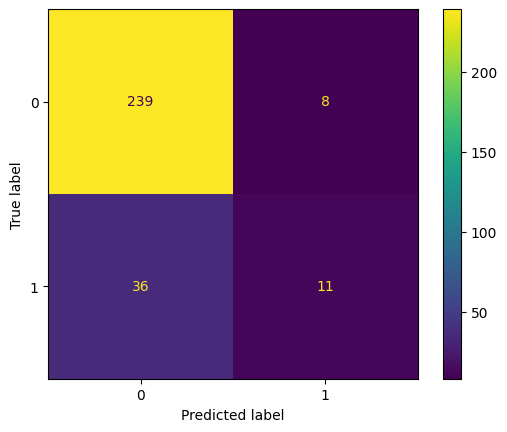

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test,
    y_test
)

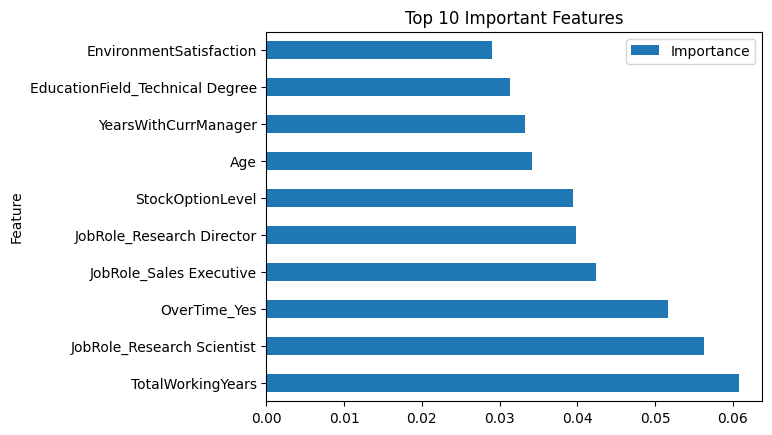

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)


importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.title('Top 10 Important Features')
plt.show()